# 03: XGBoost Lifecycle Prediction Pipeline

### [ENVIRONMENT CHECK]
Run this cell to verify your kernel and install missing dependencies.

In [12]:
import sys
import os
print(f"Kernel Python Executable: {sys.executable}")
print(f"Python Version: {sys.version}")

# Auto-install missing libraries in THIS specific kernel
!{sys.executable} -m pip install -q pandas numpy matplotlib seaborn xgboost scikit-learn

Kernel Python Executable: c:\Users\vaibh\AppData\Local\Programs\Python\Python313\python.exe
Python Version: 3.13.5 (tags/v3.13.5:6cb20a2, Jun 11 2025, 16:15:46) [MSC v.1943 64 bit (AMD64)]



[notice] A new release of pip is available: 25.1.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


**Objective:** Train and audit an optimized XGBoost classifier for 30-day user churn prediction.

In [13]:
# [STAGE 1]: Machine Learning Configuration & System Audit
%matplotlib inline
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import os
import re
from xgboost import XGBClassifier, plot_importance
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

sns.set_theme(style="whitegrid", palette="deep")

In [14]:
# [STAGE 2]: Engineered Feature Set Ingestion & Pre-modeling Audit
path = 'data/engineered_lifecycle_features.csv'
if not os.path.exists(path):
    path = '../data/engineered_lifecycle_features.csv'

df_model = pd.read_csv(path)
df_model = df_model.drop(columns=['user_id'], errors='ignore')
df_model = df_model.fillna(0) # Handling SQL NULLs from divide-by-zero
print(f"Pipeline ready. Dataset dimensions: {df_model.shape}")

Pipeline ready. Dataset dimensions: (1000, 14)


In [15]:
# [STAGE 3]: Categorical Encoding & XGBoost Feature Name Sanitization
# Transforming text features and removing library-prohibited characters
categorical_features = ['subscription_type', 'country', 'top_genre']
df_encoded = pd.get_dummies(df_model, columns=[c for c in categorical_features if c in df_model.columns], drop_first=True, dtype=int)

sanitizer = re.compile(r"\[|\]|<", re.IGNORECASE)
df_encoded.columns = [sanitizer.sub("_", col) if any(x in str(col) for x in ['[', ']', '<']) else col for col in df_encoded.columns]
df_encoded.head()

,avg_daily_minutes,number_of_playlists,skips_per_day,support_tickets,days_since_last_login,churned,intensity_percentile,negative_feedback_density,support_load_score,segment_skip_rank,...,country_PK,country_RU,country_UK,country_US,top_genre_Country,top_genre_Electronic,top_genre_Hip-Hop,top_genre_Jazz,top_genre_Pop,top_genre_Rock
0,184.6,3,7,1,0,0,0.986987,0.037920,0.005417,92,...,0,0,0,0,0,0,0,0,0,1
1,138.7,6,4,0,0,0,0.828829,0.028839,0.000000,314,...,1,0,0,0,0,0,0,0,0,1
2,90.5,3,5,0,0,0,0.434434,0.055249,0.000000,238,...,0,0,0,0,0,0,0,0,0,1
3,135.1,8,7,0,0,0,0.796797,0.051813,0.000000,92,...,0,0,0,0,0,0,0,0,1,0
4,53.6,8,0,1,0,1,0.173173,0.000000,0.018657,575,...,0,0,0,0,1,0,0,0,0,0


In [16]:
# [STAGE 4]: Data Partitioning & Type Casting for Training Stability
X = df_encoded.drop('churned', axis=1).astype(float)
y = df_encoded['churned']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
print(f"Training Partition: {X_train.shape[0]} | Validation Partition: {X_test.shape[0]}")

Training Partition: 800 | Validation Partition: 200


In [17]:
# [STAGE 5]: XGBoost Classifier Initialization & Model Fitting
clf = XGBClassifier(
    n_estimators=100, 
    learning_rate=0.06, 
    max_depth=6,
    objective='binary:logistic',
    eval_metric='auc',
    random_state=42
)
clf.fit(X_train, y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'auc'


Predictive Performance Synthesis:
               precision    recall  f1-score   support

           0       0.84      0.92      0.88       163
           1       0.41      0.24      0.31        37

    accuracy                           0.80       200
   macro avg       0.63      0.58      0.59       200
weighted avg       0.76      0.80      0.77       200



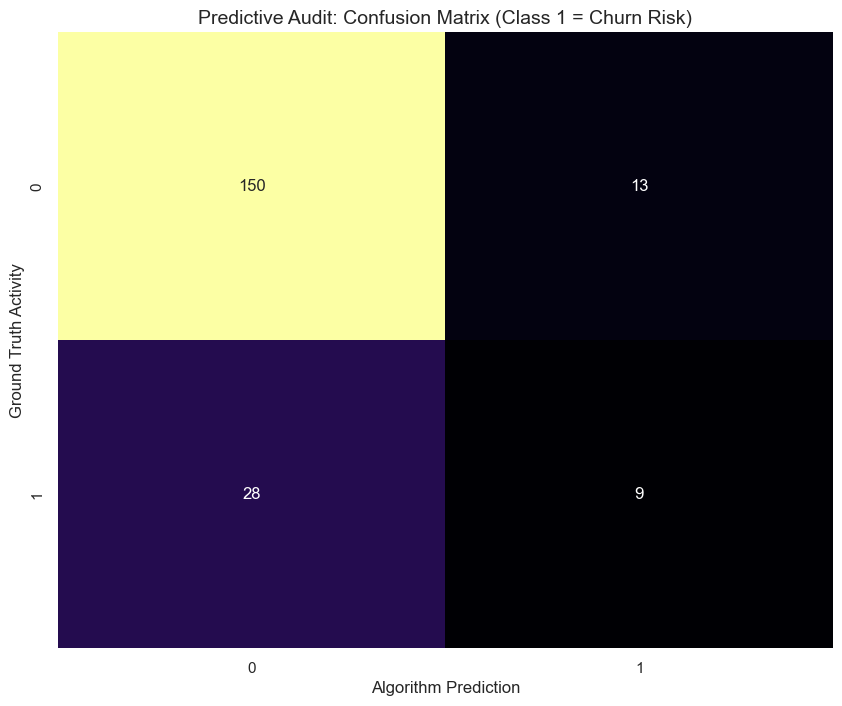

In [18]:
# [STAGE 6]: Predictive Audit: Metric Synthesis & Confusion Analysis
predictions = clf.predict(X_test)
print("Predictive Performance Synthesis:\n", classification_report(y_test, predictions))

plt.figure(figsize=(10, 8))
sns.heatmap(confusion_matrix(y_test, predictions), annot=True, fmt='d', cmap='inferno', cbar=False)
plt.title('Predictive Audit: Confusion Matrix (Class 1 = Churn Risk)', fontsize=14)
plt.xlabel('Algorithm Prediction')
plt.ylabel('Ground Truth Activity')
plt.show()

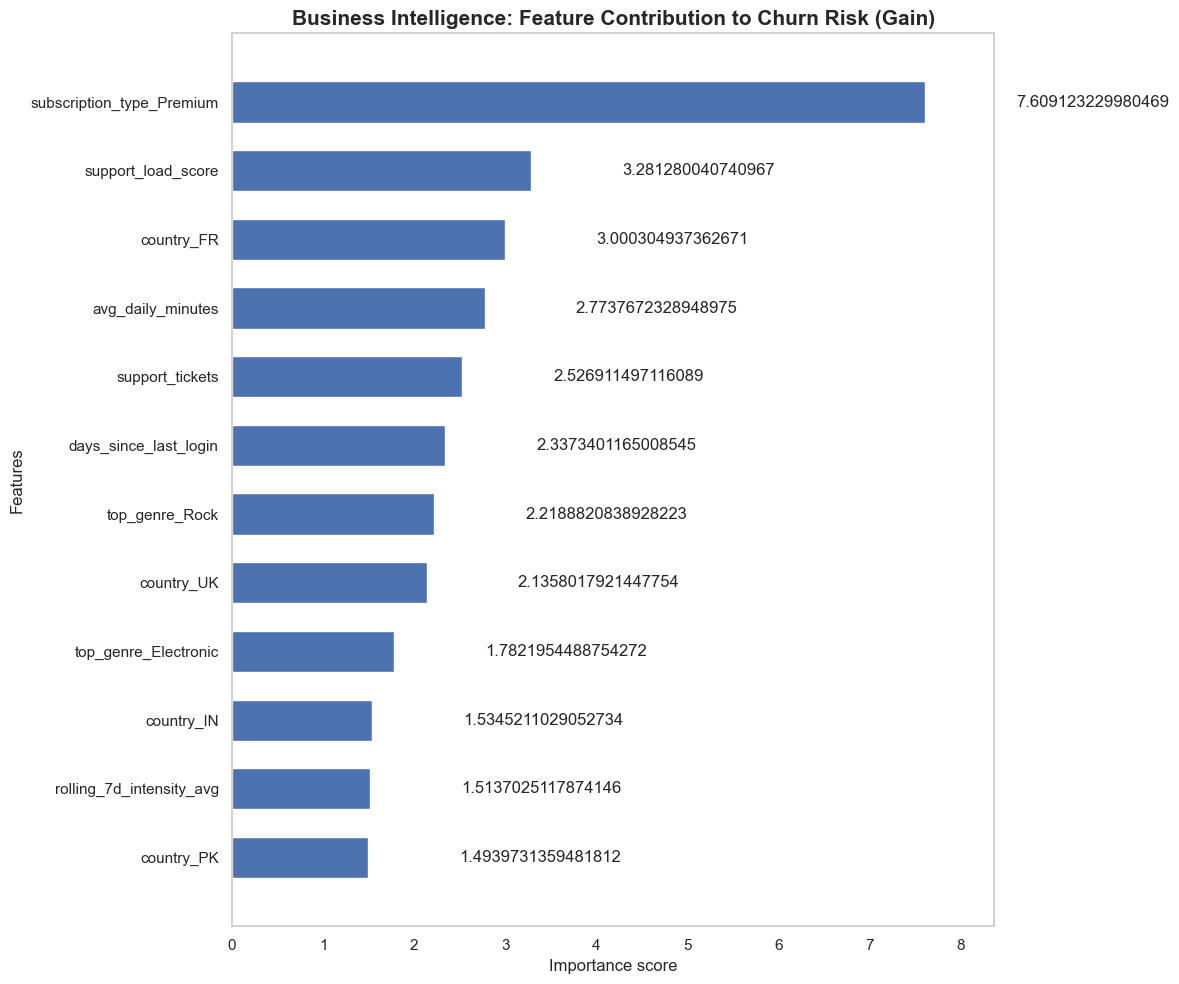

In [19]:
# [STAGE 7]: Feature Attribution: Gains Metric Importance Analysis
# Evaluating the contribution of SQL-engineered features to final model lift
fig, ax = plt.subplots(figsize=(12, 10))
plot_importance(clf, max_num_features=12, ax=ax, importance_type='gain', grid=False, height=0.6)
plt.title('Business Intelligence: Feature Contribution to Churn Risk (Gain)', fontsize=15, fontweight='bold')
plt.tight_layout()
plt.show()